**Enačbe za 3 DoF in izpisana enačba za telo 1**

$$m_1 \ddot{x}_1 
+ (c_1 + c_2) \dot{x}_1 
- c_2 \dot{x}_2 
+ (k_1 + k_2) x_1 
- k_2 x_2 
= f_1
$$


$$
\mathbf{M} =
\begin{bmatrix}
m_1 & 0   & 0   \\
0   & m_2 & 0   \\
0   & 0   & m_3
\end{bmatrix},
\quad
\mathbf{C} =
\begin{bmatrix}
c_1 + c_2 & -c_2      & 0          \\
-c_2      & c_2 + c_3 & -c_3       \\
0         & -c_3      & c_3 + c_4
\end{bmatrix},
\quad
\mathbf{K} =
\begin{bmatrix}
k_1 + k_2 & -k_2      & 0          \\
-k_2      & k_2 + k_3 & -k_3       \\
0         & -k_3      & k_3 + k_4
\end{bmatrix},

$$


$$
\mathbf{F} =
\begin{Bmatrix}
f_1 \\
f_2 \\
f_3
\end{Bmatrix},
\quad
\mathbf{x} =
\begin{Bmatrix}
x_1 \\
x_2 \\
x_3
\end{Bmatrix}
$$

$$
\mathbf{M} \ddot{\mathbf{x}} + \mathbf{C} \dot{\mathbf{x}} + \mathbf{K} \mathbf{x} = \mathbf{F}.
$$

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 

# Number of degrees of freedom (DOF)
n_dof = 5

# Define symbolic variables for masses, damping coefficients, and stiffness constants
masses = sp.symbols(f'm_1:{n_dof + 1}')  # m_1, m_2, ..., m_5
dampings = sp.symbols(f'c_1:{n_dof + 2}')  # c_1, c_2, ..., c_5
stiffnesses = sp.symbols(f'k_1:{n_dof + 2}')  # k_1, k_2, ..., k_5

# Mass matrix (diagonal)
M = sp.diag(*masses)

# Pretty printing with LaTeX format (useful for output)
sp.init_printing()

# Printing the symbolic matrices in the console
print("Mass Matrix (M):")
sp.pprint(M)



Mass Matrix (M):
⎡m₁  0   0   0   0 ⎤
⎢                  ⎥
⎢0   m₂  0   0   0 ⎥
⎢                  ⎥
⎢0   0   m₃  0   0 ⎥
⎢                  ⎥
⎢0   0   0   m₄  0 ⎥
⎢                  ⎥
⎣0   0   0   0   m₅⎦


In [2]:
dampings, stiffnesses

In [3]:
# Damping matrix (symbolic, symmetric tridiagonal)
C = sp.zeros(n_dof)
for i in range(n_dof):
    C[i, i] += dampings[i] + dampings[i + 1]
    if i < n_dof - 1:
        C[i, i + 1] -= dampings[i+1]  # Coupling with the previous block
        C[i + 1, i] -= dampings[i+1]  # Symmetric entry

# print("\nDamping Matrix (C):")
# sp.pprint(C[:4, :4])

In [4]:
# Stiffness matrix (symbolic, symmetric tridiagonal)
K = sp.zeros(n_dof)
for i in range(n_dof):
    K[i, i] += stiffnesses[i] + stiffnesses[i + 1]
    if i < n_dof - 1:
        K[i, i + 1] -= stiffnesses[i+1]  # Koupling with the previous bloKk
        K[i + 1, i] -= stiffnesses[i+1]  # Symmetric entry

print("\nStiffness Matrix (K):")
sp.pprint(K[:4, :4])


Stiffness Matrix (K):
⎡k₁ + k₂    -k₂       0        0   ⎤
⎢                                  ⎥
⎢  -k₂    k₂ + k₃    -k₃       0   ⎥
⎢                                  ⎥
⎢   0       -k₃    k₃ + k₄    -k₄  ⎥
⎢                                  ⎥
⎣   0        0       -k₄    k₄ + k₅⎦


### Nedušen sistem

$$
\mathbf{M} \ddot{\mathbf{x}} + \mathbf{K} \mathbf{x} = \mathbf{0}.
$$

$$\begin{Bmatrix}
x(t)
\end{Bmatrix}
= 
\begin{Bmatrix}
\overline{X}
\end{Bmatrix} e^{i \omega t}
$$

In [5]:
# Define the actual numerical values for masses, damping coefficients, and stiffness constants
# define masses_values for n_dof, all are equal to 1
masses_values = [1.0] * n_dof  # Example: all masses = 1 kg 
masses_values[1: 3] = 2.0, 2.0
damping_values = [0.2] * (n_dof+1) # Example: all damping coefficients = 0.2 Ns/m
stiffness_values = [100.0] * (n_dof+1)  # Example: all stiffness = 100 N/m

# Substitute the numeric values into the symbolic matrices
substituted_M = M.subs({masses[i]: masses_values[i] for i in range(n_dof)})
substituted_C = C.subs({dampings[i]: damping_values[i] for i in range(n_dof+1)})
substituted_K = K.subs({stiffnesses[i]: stiffness_values[i] for i in range(n_dof+1)})

# Pretty printing with LaTeX format (useful for output)
sp.init_printing()

# Printing the substituted numeric matrices
print("Mass Matrix (M) with substituted values:")
sp.pprint(substituted_M[:5, :5])

# print("\nDamping Matrix (C) with substituted values:")
# sp.pprint(substituted_C[:5, :5])

print("\nStiffness Matrix (K) with substituted values:")
sp.pprint(substituted_K[:5, :5])



Mass Matrix (M) with substituted values:
⎡1.0   0    0    0    0 ⎤
⎢                       ⎥
⎢ 0   2.0   0    0    0 ⎥
⎢                       ⎥
⎢ 0    0   2.0   0    0 ⎥
⎢                       ⎥
⎢ 0    0    0   1.0   0 ⎥
⎢                       ⎥
⎣ 0    0    0    0   1.0⎦

Stiffness Matrix (K) with substituted values:
⎡200.0   -100.0    0       0       0   ⎤
⎢                                      ⎥
⎢-100.0  200.0   -100.0    0       0   ⎥
⎢                                      ⎥
⎢  0     -100.0  200.0   -100.0    0   ⎥
⎢                                      ⎥
⎢  0       0     -100.0  200.0   -100.0⎥
⎢                                      ⎥
⎣  0       0       0     -100.0  200.0 ⎦


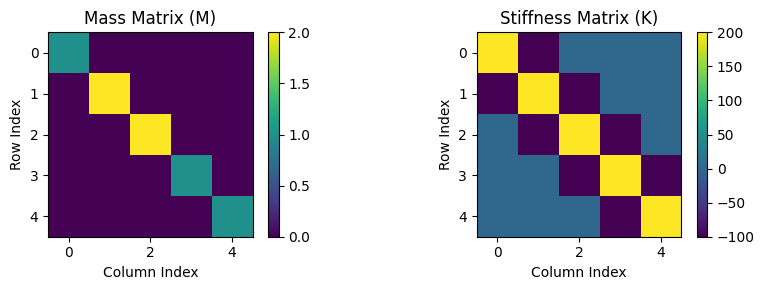

In [56]:
# Function to plot matrices as heatmaps
def plot_matrix(matrix, title):
    plt.figure(figsize=(4, 3))
    plt.imshow(np.array(matrix).astype(np.float64), cmap="viridis", interpolation="nearest")
    plt.colorbar(label="Value")
    plt.title(title)
    plt.xlabel("Column Index")
    plt.ylabel("Row Index")
    plt.show()

# Plot the matrices side by side
def plot_matrices_side_by_side(matrices, titles):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))  # 1 row, 3 columns
    for ax, matrix, title in zip(axes, matrices, titles):
        im = ax.imshow(np.array(matrix).astype(np.float64), cmap="viridis", interpolation="nearest")
        ax.set_title(title)
        ax.set_xlabel("Column Index")
        ax.set_ylabel("Row Index")
        fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Matrices and titles
matrices = [substituted_M, substituted_C, substituted_K]
titles = ["Mass Matrix (M)", "Damping Matrix (C)", "Stiffness Matrix (K)"]

# Matrices and titles
matrices = [substituted_M, substituted_K]
titles = ["Mass Matrix (M)", "Stiffness Matrix (K)"]

# Plot the matrices
plot_matrices_side_by_side(matrices, titles)


In [7]:
#convert substituted matrices to np.array
M = np.array(substituted_M).astype(np.float64)
C = np.array(substituted_C).astype(np.float64)
K = np.array(substituted_K).astype(np.float64)

$$
\begin{bmatrix}
A
\end{bmatrix}
= 

\begin{bmatrix}
\begin{bmatrix}
K
\end{bmatrix}
- 
\omega^2
\begin{bmatrix}
M
\end{bmatrix}
\end{bmatrix}
$$

In [8]:
A = np.linalg.inv(M)@K
print(A.shape)
A[:6, :6]

(5, 5)


array([[ 200., -100.,    0.,    0.,    0.],
       [ -50.,  100.,  -50.,    0.,    0.],
       [   0.,  -50.,  100.,  -50.,    0.],
       [   0.,    0., -100.,  200., -100.],
       [   0.,    0.,    0., -100.,  200.]])

#### Lastne vrednosti, oblike, sortiranje

In [ ]:
w, v = np.linalg.eig(A)
idx = w.argsort()[::1]
w = w[idx]
v = v[:, idx]
print("Lastne frekvence:")
for i in range(len(w)):
    print(f"{np.sqrt(w[i]):.3f} rad/s")

Lastne frekvence:
4.078 rad/s
8.940 rad/s
12.247 rad/s
15.494 rad/s
17.702 rad/s


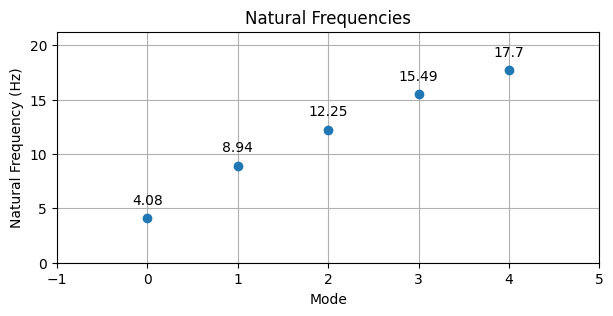

In [59]:
fig, ax = plt.subplots(figsize=(5+ n_dof*0.4, 3))
ax.plot(np.sqrt(w.real), 'o')
ax.set_xlabel('Mode')
ax.set_ylabel('Natural Frequency (Hz)')
ax.set_title('Natural Frequencies')
ax.set_ylim([0, 1.2*np.sqrt(max(w.real))])
ax.set_xlim([-1, n_dof])
for i, txt in enumerate(np.round(np.sqrt(w.real), 2)):
    ax.annotate(txt, (i, np.sqrt(w.real)[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.grid()
plt.show()

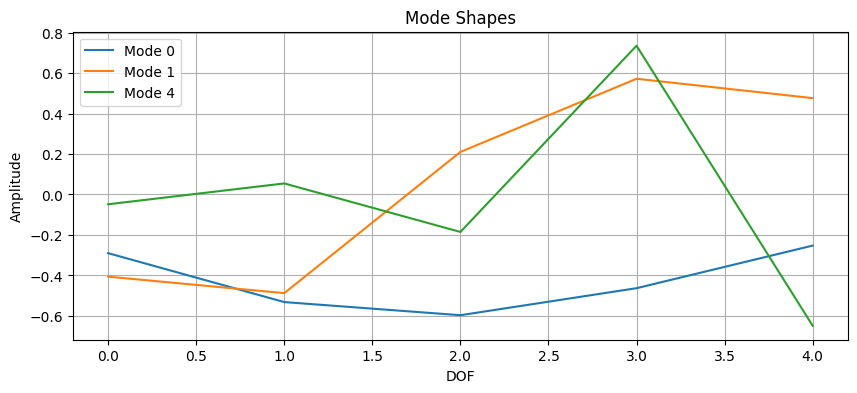

In [11]:
# plot mode shapes all in one plot only different colors. let me define which modes to show
modes = [0, 1, 4]
fig, ax = plt.subplots(figsize=(10, 4))
for i in modes:
    ax.plot(v[:, i], label=f'Mode {i}')
ax.set_xlabel('DOF')
ax.set_ylabel('Amplitude')
ax.set_title('Mode Shapes')
ax.legend()
plt.grid()
plt.show()

#### Preverjanje ortogonalnosti lastnih vektorjev

In [12]:
s = 1 #indeks 1
r = 2 #indeks 2
v[:, s].T @  M @ v[:, r]

Matrika modalnih mas


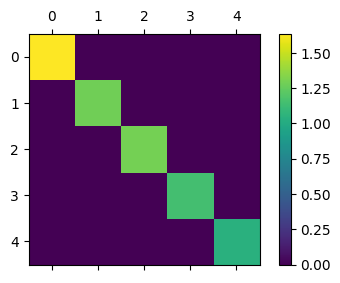

In [13]:
print("Matrika modalnih mas")
fig, ax = plt.subplots(figsize=(3+ n_dof*0.4, 3 ))
ax.imshow(v.T @ M @ v, cmap='viridis')
fig.colorbar(ax.matshow(v.T @ M @ v, cmap='viridis'))

#### Modal mass and stiffness

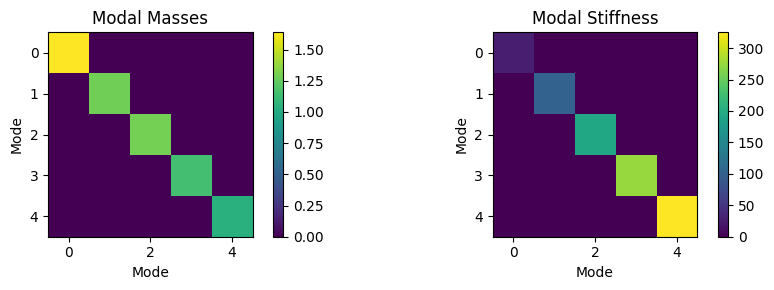

Modal Mass 0: 1.64 kg
Modal Mass 1: 1.28 kg
Modal Mass 2: 1.29 kg
Modal Mass 3: 1.15 kg
Modal Mass 4: 1.04 kg


In [14]:
#define modal stiffness and modal masses 
modal_stiffness = v.T @ K @ v
modal_masses = v.T @ M @ v
# plot modal masses and modal stiffness with imshhow
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
im1 = ax[0].imshow(modal_masses, cmap='viridis')
ax[0].set_title('Modal Masses')
ax[0].set_xlabel('Mode')
ax[0].set_ylabel('Mode')
fig.colorbar(im1, ax=ax[0], orientation='vertical')
im2 = ax[1].imshow(modal_stiffness, cmap='viridis')
ax[1].set_title('Modal Stiffness')
ax[1].set_xlabel('Mode')
ax[1].set_ylabel('Mode')
fig.colorbar(im2, ax=ax[1], orientation='vertical')
plt.tight_layout()
plt.show()


for i in range(len(modal_masses)):
    print(f'Modal Mass {i}: {modal_masses[i, i]:.2f} kg')


#### Masno normiranje

In [15]:
D = np.zeros((n_dof, n_dof))
for i in range(n_dof):
    D[i, i] = 1/np.sqrt(modal_masses[i, i])
    
Phi = v.copy()
for i in range(n_dof):
    Phi[:,i] =  Phi[:,i]*D[i,i]

1.0
1.0000000000000002
1.0
1.0000000000000002
1.0


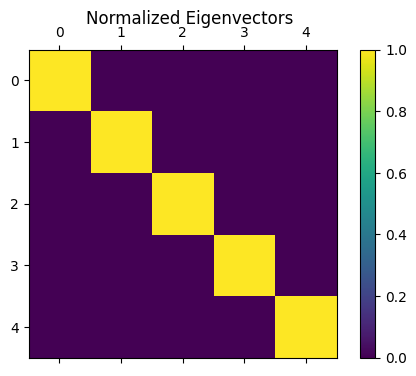

In [ ]:
# Prikaz normiranih lastnih  vektorjev
graf1 = Phi.T @ M @ Phi
#imshow graf
fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
fig.suptitle('Normalized Eigenvectors')
ax.imshow(graf1, cmap='viridis')
fig.colorbar(ax.matshow(graf1, cmap='viridis'))
for i in range(n_dof):
    print(graf1[i,i])

In [17]:
# Prikaz normiranih lastnih  vektorjev
graf2 = Phi.T @ K @ Phi
#imshow graf
# fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
# ax.imshow(graf2, cmap='viridis')
# fig.colorbar(ax.matshow(graf2, cmap='viridis'))
for i in range(n_dof):
    print(graf2[i,i])
print("-----------------")
for i in range(n_dof):
    print(w[i])

16.62986631453686
79.93240846589666
150.0
240.06098640904378
313.3767388105228
-----------------
16.629866314536876
79.93240846589663
150.0
240.06098640904384
313.3767388105225


#### Preverjanje modalnih mas
Spodaj preverimo, če se izračun lastnih frekvenc z modalnimi vrednostmi (masami, togostmi) sklada s standardnim izračunom modalne analize.

In [18]:
A_2 = np.linalg.inv(modal_masses)@modal_stiffness
w_2, v_2 = np.linalg.eig(A_2);

idx = w_2.argsort()[::1]
w_2 = w_2[idx]
v_2 = v_2[:,idx]


print("-------------------------")
print("Primerjava lastnih frekvenc:")
for i in range(5):
    print(f"Mode {i}: {np.sqrt(w[i]):.3f} Hz, {np.sqrt(w_2[i]):.3f} Hz")

-------------------------
Primerjava lastnih frekvenc:
Mode 0: 4.078 Hz, 4.078 Hz
Mode 1: 8.940 Hz, 8.940 Hz
Mode 2: 12.247 Hz, 12.247 Hz
Mode 3: 15.494 Hz, 15.494 Hz
Mode 4: 17.702 Hz, 17.702 Hz


$$
\lambda_r = \frac{k_r}{m_r}
$$

Modal Masses:
Mode 0: 1.64 kg
Mode 1: 1.28 kg
Mode 2: 1.29 kg
Mode 3: 1.15 kg
Mode 4: 1.04 kg


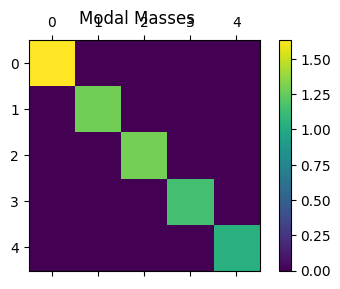

In [19]:
#imshow modalmasses
fig, ax = plt.subplots(figsize=(3+ n_dof*0.4, 3 ))
fig.suptitle('Modal Masses')
ax.imshow(modal_masses, cmap='viridis')
fig.colorbar(ax.matshow(modal_masses, cmap='viridis'))


print("Modal Masses:")
for i in range(5):
    print(f"Mode {i}: {modal_masses[i, i]:.2f} kg")

Modal stiffneses:
Mode 0: 27.24 N/m
Mode 1: 102.45 N/m
Mode 2: 194.12 N/m
Mode 3: 275.15 N/m
Mode 4: 325.04 N/m


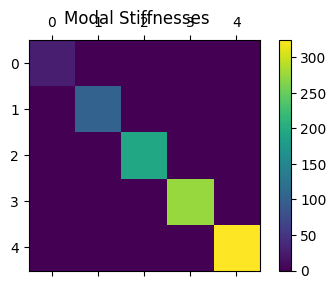

In [20]:
#imshow modalmasses
fig, ax = plt.subplots(figsize=(3+ n_dof*0.4, 3 ))
fig.suptitle('Modal Stiffnesses')
ax.imshow(modal_stiffness, cmap='viridis')
fig.colorbar(ax.matshow(modal_stiffness, cmap='viridis'))

print("Modal stiffneses:")
for i in range(5):
    print(f"Mode {i}: {modal_stiffness[i, i]:.2f} N/m")

In [21]:
A_3 = np.linalg.inv(modal_masses)@modal_stiffness
w_3, v_3 = np.linalg.eig(A_3);

idx = w_3.argsort()[::1]
w_3 = w_3[idx]
v_3 = v_3[:,idx]

print("Lastne frekvence z modalnimi masami:")
for i in range(5):
    print(f"{np.sqrt(w_3[i]):.3f} Hz")

print("-------------------------")
print("Primerjava lastnih frekvenc:")
for i in range(5):
    print(f"Mode {i}: {np.sqrt(w_3[i]):.3f} Hz, {np.sqrt(w_2[i]):.3f} Hz")

Lastne frekvence z modalnimi masami:
4.078 Hz
8.940 Hz
12.247 Hz
15.494 Hz
17.702 Hz
-------------------------
Primerjava lastnih frekvenc:
Mode 0: 4.078 Hz, 4.078 Hz
Mode 1: 8.940 Hz, 8.940 Hz
Mode 2: 12.247 Hz, 12.247 Hz
Mode 3: 15.494 Hz, 15.494 Hz
Mode 4: 17.702 Hz, 17.702 Hz


### Admitanca

*Definicija vektorja frekvenc*

In [22]:
omega = np.linspace(1, 100, 100)

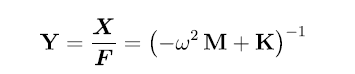

In [23]:
print("Oblike matrik:")
print("M:")
print(M.shape)
print("K:")
print(K.shape)
print("omega:")
print(omega.shape)

Oblike matrik:
M:
(5, 5)
K:
(5, 5)
omega:
(100,)


In [24]:
Y_einsum = np.linalg.inv(-omega[:,None,None]**2 * M[None,:,:] + K[None,:,:])
Y_einsum.shape

In [25]:
Y = np.zeros((len(omega), M.shape[0], M.shape[1]))

for i in range(len(omega)):
    Y[i] = np.linalg.inv(-omega[i]**2*M + K)

print("Y shape:")
print(Y.shape)

Y shape:
(100, 5, 5)


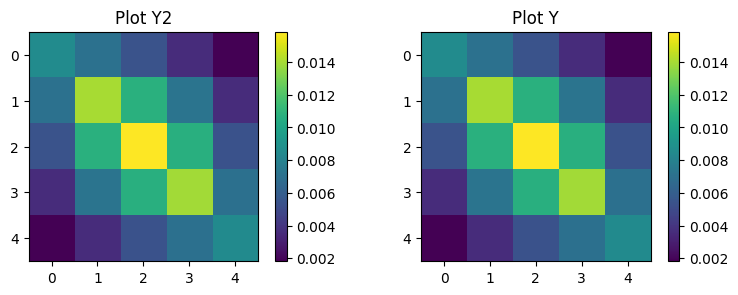

In [26]:
fig, axs = plt.subplots(ncols=2, figsize=(6 + n_dof*0.4, 3))  # Two columns for side-by-side plots

# First plot on the left
im0 = axs[0].imshow(Y[0], cmap='viridis')
fig.colorbar(im0, ax=axs[0])  # Colorbar for the first plot
axs[0].set_title('Plot Y2')

# Second plot on the right
im1 = axs[1].imshow(Y_einsum[0], cmap='viridis')  # You can change this to another array if needed
fig.colorbar(im1, ax=axs[1])  # Colorbar for the second plot
axs[1].set_title('Plot Y')

plt.tight_layout()
plt.show()

In [27]:
(Y == Y_einsum).all()

np.True_

### Admitanca 2

In [28]:
# Phi, w
Phi.shape

In [29]:
import numpy as np

modal_shapes_l_limit = 0
modal_shapes_u_limit = 5
idx_w = np.arange(modal_shapes_l_limit, modal_shapes_u_limit, 1) #index za lastne frekvence
omega_r = w[modal_shapes_l_limit:modal_shapes_u_limit] # lastne frekvence

o_l_limit = 0 # Spodnja meja output
o_u_limit = 5 # zgornja meja ouput

i_l_limit = 0 # Spodnja meja input
i_u_limit = 5 # zgornja meja input

Phi_output = Phi[o_l_limit:o_u_limit,modal_shapes_l_limit:modal_shapes_u_limit].copy()
Phi_input = Phi[i_l_limit:i_u_limit, modal_shapes_l_limit:modal_shapes_u_limit].copy()

print(f'Število modalnih oblik: {modal_shapes_u_limit - modal_shapes_l_limit}')
print(f'Oblika Phi_O: {Phi_output.shape}')
print(f'Oblika Phi_I: {Phi_input.shape}')
print(f'Oblika Phi_I.T: {Phi_input.T.shape}')
print(f'Omega: {omega_r.shape}')

Število modalnih oblik: 5
Oblika Phi_O: (5, 5)
Oblika Phi_I: (5, 5)
Oblika Phi_I.T: (5, 5)
Omega: (5,)


$
\mathbf{Y} \approx \frac{\mathbf{\Phi} \mathbf{\Phi}^{\top}}{-\omega^2 \mathbf{I} + \omega_r^2}
= \sum_{r=1}^{m} \frac{r \, \boldsymbol{\phi}_r \boldsymbol{\phi}_r^{\top}}{-\omega^2 + \omega_r^2}
= \sum_{r=1}^{m} \frac{r \mathbf{A}}{-\omega^2 + \omega_r^2},
$


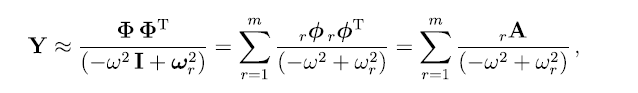

In [30]:
Phi_output.shape, Phi_input.shape, Phi_input.T.shape, (Phi_output@Phi_input.T).shape

In [31]:
Phi_output[:, [0]]

array([[-0.22645173],
       [-0.41524484],
       [-0.46592862],
       [-0.36164579],
       [-0.19722175]])

In [32]:
Phi_input[:, [0]].T

array([[-0.22645173, -0.41524484, -0.46592862, -0.36164579, -0.19722175]])

In [33]:
Phi_output[:, [0]] @ Phi_input[:, [0]].T

array([[0.05128039, 0.09403291, 0.10551034, 0.08189532, 0.04466121],
       [0.09403291, 0.17242827, 0.19347446, 0.15017155, 0.08189532],
       [0.10551034, 0.19347446, 0.21708948, 0.16850113, 0.09189126],
       [0.08189532, 0.15017155, 0.16850113, 0.13078768, 0.07132442],
       [0.04466121, 0.08189532, 0.09189126, 0.07132442, 0.03889642]])

In [34]:
bla = np.array([1,2,3])
# vrstica
bla[np.newaxis].shape

# stolpec
# bla[:, np.newaxis].shape

In [35]:
blabla = np.array([[1,2,3], [4,5,6]])

In [36]:
r_A = Phi_output[:, [0]] @ Phi_input[:, [0]].T
imenovalec = 1. / (omega_r[0]**2 - omega[0]**2)
# Y_2[i] = 
r_A * imenovalec

array([[0.0001861 , 0.00034125, 0.0003829 , 0.0002972 , 0.00016208],
       [0.00034125, 0.00062575, 0.00070213, 0.00054498, 0.0002972 ],
       [0.0003829 , 0.00070213, 0.00078783, 0.0006115 , 0.00033348],
       [0.0002972 , 0.00054498, 0.0006115 , 0.00047464, 0.00025884],
       [0.00016208, 0.0002972 , 0.00033348, 0.00025884, 0.00014116]])

In [37]:
r_A = Phi_output[:, [1]] @ Phi_input[:, [1]].T
imenovalec = 1. / (omega_r[1]**2 - omega[0]**2)
# Y_2[i] = 
r_A * imenovalec

array([[ 2.01188871e-05,  2.41562632e-05, -1.04237267e-05,
        -2.83398450e-05, -2.36032427e-05],
       [ 2.41562632e-05,  2.90038434e-05, -1.25155175e-05,
        -3.40269693e-05, -2.83398450e-05],
       [-1.04237267e-05, -1.25155175e-05,  5.40060078e-06,
         1.46830586e-05,  1.22289940e-05],
       [-2.83398450e-05, -3.40269693e-05,  1.46830586e-05,
         3.99200417e-05,  3.32479741e-05],
       [-2.36032427e-05, -2.83398450e-05,  1.22289940e-05,
         3.32479741e-05,  2.76910477e-05]])

In [38]:
# Y_2 = np.zeros((len(omega), Phi_output.shape[0], Phi_input.shape[0]))
# Y_2.shape

In [49]:
# Y_2 = np.zeros((len(omega), Phi_output.shape[0], Phi_input.shape[0]))

# for i in range(len(omega)):
#     for j in range(len(omega_r)):
#         r_A = Phi_output[:, [j]] @ Phi_input[:, [j]].T
#         imenovalec = 1. / (omega_r[j]**2 - omega[i]**2)
#         # Y_2[i] = 
#         Y_2[i] += r_A * imenovalec
        
stevec = np.einsum('om, im -> moi', Phi_output, Phi_input)
imenovalec = 1. / (-omega[:,None]**2 + omega_r**2)
kvocient = np.einsum('moi, fm -> foi', stevec, imenovalec)
kvocient.shape

In [48]:
Y_2_einsum = np.einsum('om, im, fm -> foi', Phi_output, Phi_input, 1. / (-omega[:,None]**2 + omega_r**2))
Y_2_einsum.shape

In [54]:
(kvocient[2] == Y_2_einsum[2])

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True, False],
       [ True,  True,  True, False, False]])

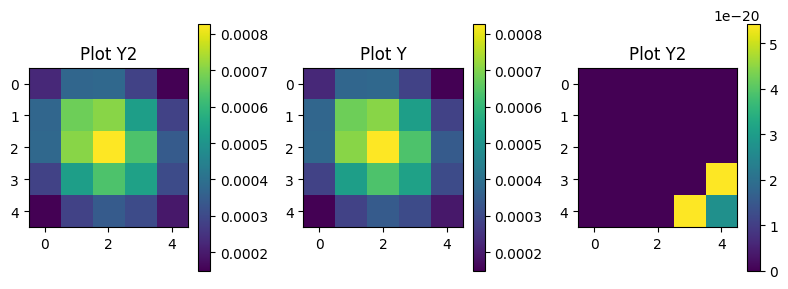

In [52]:
# (Y_2 == Y_2_einsum).all()
fig, axs = plt.subplots(ncols=3, figsize=(6 + n_dof*0.4, 3))  # Two columns for side-by-side plots

# First plot on the left
im0 = axs[0].imshow(kvocient[2], cmap='viridis')
fig.colorbar(im0, ax=axs[0])  # Colorbar for the first plot
axs[0].set_title('Plot Y2')

# Second plot on the right
im1 = axs[1].imshow(Y_2_einsum[2], cmap='viridis')  # You can change this to another array if needed
fig.colorbar(im1, ax=axs[1])  # Colorbar for the second plot
axs[1].set_title('Plot Y')

# First plot on the left
im0 = axs[2].imshow(kvocient[2] - Y_2_einsum[2], cmap='viridis')
fig.colorbar(im0, ax=axs[2])  # Colorbar for the first plot
axs[2].set_title('Plot Y2')

plt.tight_layout()
plt.show()

In [ ]:
Phi_output[:, [0]] @ Phi_input[:, [0]].T

array([[0.05128039, 0.09403291, 0.10551034],
       [0.09403291, 0.17242827, 0.19347446],
       [0.10551034, 0.19347446, 0.21708948],
       [0.08189532, 0.15017155, 0.16850113]])

In [ ]:
print(f'Število lastnih oblik: {len(idx_w)}')

# seštevanje po modalnih oblikah
for i in idx_w:
    r_A = Phi_output @ Phi_input.T
    r_A[:, :, None].transpose(2, 0, 1)
    
    i_A = -omega**2 + w[idx_w[i]]**2
    i_A = i_A[:, None, None]
    Y2 += r_A/ i_A
    
Y2[0, :, :]
# print(f"Phi_output shape: {Phi_output.shape}")
# print(f"Phi_input shape: {Phi_input.shape}")
# print(f"r_A shape: {r_A.shape}")
# print(f"i_A shape: {i_A.shape}")
# print(f"Y2 shape: {Y2.shape}")


fig, axs = plt.subplots(ncols=2, figsize=(6 + n_dof*0.4, 3))  # Two columns for side-by-side plots

# First plot on the left
im0 = axs[0].imshow(Y2[2], cmap='viridis')
fig.colorbar(im0, ax=axs[0])  # Colorbar for the first plot
axs[0].set_title('Plot Y2')

# Second plot on the right
im1 = axs[1].imshow(Y[2], cmap='viridis')  # You can change this to another array if needed
fig.colorbar(im1, ax=axs[1])  # Colorbar for the second plot
axs[1].set_title('Plot Y')

plt.tight_layout()
plt.show()

Število lastnih oblik: 2


NameError: name 'Y2' is not defined

In [ ]:
# fig, ax = plt.subplots(figsize=(6, 4))

# ax.plot(omega, np.abs(Y2[:, 0, 0]), label='Phi_1')
# ax.plot(omega, np.abs(Y2[:, 1, 0]), label='Phi_2')
# ax.plot(omega, np.abs(Y2[:, 2, 0]), label='Phi_3')

# ax.set_yscale('log')  # Set y-axis to logarithmic scale
# ax.legend(loc=(1.01, 0))  # Add legend
# ax.set_xlabel('Omega')  # Label x-axis
# ax.set_ylabel('Magnitude')  # Label y-axis
# ax.grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid

# plt.show()


#### test

In [ ]:
# Predpostavimo primer: 4 output lokacije, 3 input lokacije in 2 moda

# levi r_Phi je dimenzije [4x2]
r_phi_out = np.random.random((4,2))

# desni r_Phi je dimenzije [3x2] (oz. [2x3] ko transponirate)
r_phi_inp = np.random.random((3,2))

# produkt torej 4x3
r_stevec = r_phi_out @ r_phi_inp.T
print('r-ti števec:', r_stevec.shape)

#imenovalec ima dolžino vektorja omega, npr. 1000
omega = np.random.random(1000)
r_omega = 1
r_imenovalec = -omega**2 + r_omega**2
print('r-ti imenovalec:', r_imenovalec.shape)

# dokaj elegantna izvedba deljenja
r_clen = r_stevec[:,:,None].transpose(2,0,1) / r_imenovalec[:,None, None]
print('r-ti člen:', r_clen.shape)

# potem pa npr. zlaganje takih členov v tenzor in vsota / vsota v for loopu ali kaj podobnega
# bolj elegantno gre vse skupaj tudi z np.einsum, če želite naštudir

r-ti števec: (4, 3)
r-ti imenovalec: (1000,)
r-ti člen: (1000, 4, 3)
